# 10 · SSVEP: spectral peaks and canonical correlation

**ROBT613 · Brain–Computer Interfaces** | 90–120 min

## Goal
Decode 12 versus 15 Hz visual stimulation using spectral signal-to-noise ratio and a sinusoidal-reference CCA decoder.

**Data:** Native MNE SSVEP dataset, participant 02

Run cells from top to bottom in a fresh CPU runtime. No previous notebook state is required.

## Setup
The first cell installs the tested core versions in Colab. Downloads are cached in `mne_data/`; a new Colab runtime loses that cache. A failed download is an error, never silently replaced by synthetic data.

In [1]:
# Colab: install before importing numerical libraries. Restart if pip requests it.
import sys, subprocess, os
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'mne==1.13.2', 'moabb==1.7.2'])
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from scipy import signal
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (balanced_accuracy_score, roc_auc_score,
                             ConfusionMatrixDisplay, classification_report)
from sklearn.model_selection import (GroupKFold, cross_validate, GridSearchCV)
SEED = 613
rng = np.random.default_rng(SEED)
DATA_ROOT = Path(os.environ.get('BCI_DATA', './mne_data')).resolve()
DATA_ROOT.mkdir(parents=True, exist_ok=True)
os.environ['MNE_DATA'] = str(DATA_ROOT)
mne.set_log_level('WARNING')
plt.rcParams.update({'figure.figsize': (9, 4), 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
import importlib.metadata as metadata
print({p: metadata.version(p) for p in ['mne','moabb','numpy','scipy','scikit-learn']})
print('Dataset cache:', DATA_ROOT)

{'mne': '1.13.2', 'moabb': '1.7.2', 'numpy': '2.1.3', 'scipy': '1.15.3', 'scikit-learn': '1.6.1'}
Dataset cache: ./mne_data


## Concepts and mathematics

SSVEP uses periodic visual stimulation to produce narrowband responses near the stimulus frequency and its harmonics. This differs from the transient ERP and self-paced motor-imagery paradigms. This recording is a frequency-tagging experiment, not a many-character online speller.

A local spectral SNR is $SNR(f)=P(f)/\mathrm{mean}_{g\in\mathcal N(f)}P(g)$, where neighboring bins exclude the center and guard bins. Guard bins avoid counting spectral leakage as background. A spectral maximum can be contaminated by spontaneous alpha, so occipital channels and harmonics help.

Canonical correlation chooses $a,b$ to maximize $\rho=\mathrm{corr}(X^Ta,Y_f^Tb)$, where $Y_f$ contains $\sin(2\pi hft)$ and $\cos(2\pi hft)$ for harmonics $h$. The frequency with the largest canonical correlation is selected. Fitting CCA to an individual test epoch and its known reference is part of this label-free decoder, not supervised training on its true label. Selecting channels, harmonics or window length using test accuracy would still leak.

## Load native MNE SSVEP data
The event mapping follows the dataset’s documented stimulus codes. Keep one decision per original trial.

In [2]:
path=mne.datasets.ssvep.data_path(path=DATA_ROOT,update_path=False)
fname=path/'sub-02'/'ses-01'/'eeg'/'sub-02_ses-01_task-ssvep_eeg.vhdr'
raw=mne.io.read_raw_brainvision(fname,preload=True,verbose=False)
raw.set_montage('easycap-M1')
raw.set_eeg_reference('average',projection=False)
raw.filter(1,40)
events,_=mne.events_from_annotations(raw,event_id={'Stimulus/S255':12,'Stimulus/S155':15})
epochs=mne.Epochs(raw,events,{'12 Hz':12,'15 Hz':15},1,5,baseline=None,
                  picks=['O1','Oz','O2'],preload=True)
X=epochs.get_data(copy=True)
y=epochs.events[:,2]
print('Original-trial decisions:',len(y), 'classes:',np.unique(y))

Original-trial decisions: 20 classes: [12 15]


## Measure spectral evidence
A four-second window has approximately 0.25 Hz native resolution.

Fixed SNR rule balanced accuracy: 0.95


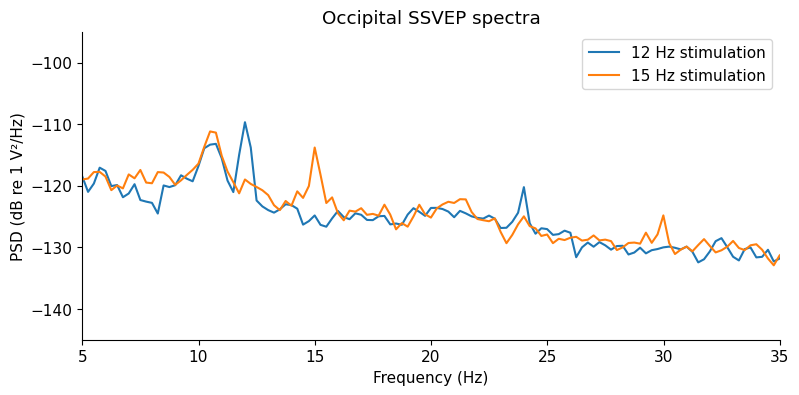

In [3]:
f,P=signal.welch(X,fs=epochs.info['sfreq'],nperseg=X.shape[-1],axis=-1)
P=P.mean(axis=1)
snr=[]
for target in [12,15]:
    idx=np.argmin(abs(f-target))
    neighbors=np.r_[idx-5:idx-1,idx+2:idx+6]
    snr.append(P[:,idx]/P[:,neighbors].mean(axis=1))
snr=np.asarray(snr).T
pred=np.array([12,15])[snr.argmax(1)]
print('Fixed SNR rule balanced accuracy:',balanced_accuracy_score(y,pred))
fig,ax=plt.subplots()
for target in [12,15]:
    ax.plot(f,10*np.log10(P[y==target].mean(0)),label=f'{target} Hz stimulation')
ax.set(xlim=(5,35),ylim=(-145,-95),xlabel='Frequency (Hz)',ylabel='PSD (dB re 1 V²/Hz)',title='Occipital SSVEP spectra')
ax.legend(); plt.show()

## Implement CCA classification
Use two harmonics and identical reference length for each trial.

Fixed CCA rule balanced accuracy: 1.0


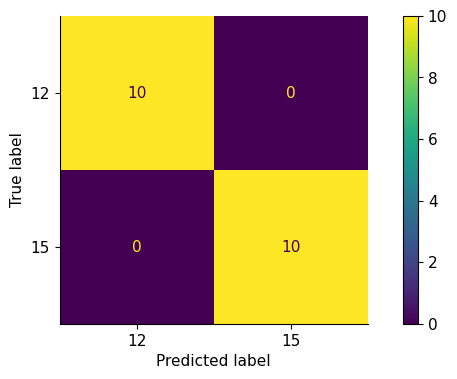

In [4]:
from sklearn.cross_decomposition import CCA
def cca_score(epoch, frequency, sfreq, harmonics=2):
    t=np.arange(epoch.shape[-1])/sfreq
    reference=np.stack([fn(2*np.pi*h*frequency*t)
                        for h in range(1,harmonics+1) for fn in (np.sin,np.cos)],axis=1)
    cca=CCA(n_components=1,max_iter=1000)
    u,v=cca.fit_transform(epoch.T,reference)
    return abs(np.corrcoef(u[:,0],v[:,0])[0,1])
score=np.array([[cca_score(epoch,freq,epochs.info['sfreq']) for freq in [12,15]] for epoch in X])
pred=np.array([12,15])[score.argmax(1)]
print('Fixed CCA rule balanced accuracy:',balanced_accuracy_score(y,pred))
ConfusionMatrixDisplay.from_predictions(y,pred); plt.show()

## Exercises and checks
1. Compare 1, 2 and 4 second windows as a predeclared sensitivity analysis.
2. Why does a 10 Hz alpha peak not imply 10 Hz visual attention?
3. Add a rejection option when both correlations are low; calibrate its threshold on separate trials.
4. Design a train/test split that keeps all subwindows of one trial together.
5. Discuss visual comfort and photosensitivity before proposing any live flicker experiment.

## Next steps and sources
[MNE SSVEP tutorial and provenance](https://mne.tools/stable/auto_tutorials/time-freq/50_ssvep.html) · [CCA API](https://scikit-learn.org/stable/modules/generated/sklearn.cross_decomposition.CCA.html).

Record package versions, subject/run IDs, preprocessing, split unit, random seed, and all exclusions with your results. Do not interpret a single participant as a population estimate.